# Laboratório 06: Validador de Expressões Matemáticas (LIFO)
**Objetivo:** Utilizar a estrutura de dados Pilha (Stack), baseada na política LIFO (Last-In, First-Out), para criar um analisador sintático capaz de validar o balanceamento de parênteses, colchetes e chaves em expressões matemáticas.
**Metodologia:** Pair Programming (Programação em Pares). 
**Navegador:** [Nome do Aluno 1] | **Motorista:** [Nome do Aluno 2]

## 1. O Problema e a Arquitetura
Como vimos na teoria, em uma **Pilha**, o último elemento a entrar deve ser o primeiro a sair. 
Isso se encaixa perfeitamente no problema de fechamento de símbolos matemáticos: o último símbolo aberto deve ser, obrigatoriamente, o primeiro a ser fechado.

**O Algoritmo:**
1. Varrer a string caractere por caractere.
2. Se achar uma abertura `(`, `[`, `{`, empurre para a pilha (**Push**).
3. Se achar um fechamento `)`, `]`, `}`, remova do topo da pilha (**Pop**) e verifique se eles formam o par correto.
4. Dica: Lembre-se de verificar se a pilha já não está vazia antes de dar o `pop()` para evitar um erro no Python!

## 2. Aquecimento: O Validador Simples (Apenas Parênteses)
Antes de criar o validador completo, vamos começar com uma versão mais simples que lida apenas com parênteses `()`.
A lógica será a mesma: se encontrar um `(`, empurre para a pilha (PUSH). Se encontrar um `)`, remova do topo (POP).
Neste passo inicial, o Navegador deve codificar junto com o Motorista.

In [7]:
def validar_parenteses(expressao: str) -> bool:
    pilha = []
    
    for caractere in expressao:
        if caractere == '(':
            pilha.append(caractere)
        elif caractere == ')':
            if len(pilha) == 0:
                return False
            pilha.pop()
            
    return len(pilha) == 0

# Testando o validador simples
print("Teste Correto (a+b):", validar_parenteses("(a + b)"))
print("Teste Incorreto (a+b)):", validar_parenteses("(a + b))"))
print("Teste Incompleto ((a+b):", validar_parenteses("((a + b)"))

Teste Correto (a+b): True
Teste Incorreto (a+b)): False
Teste Incompleto ((a+b): False


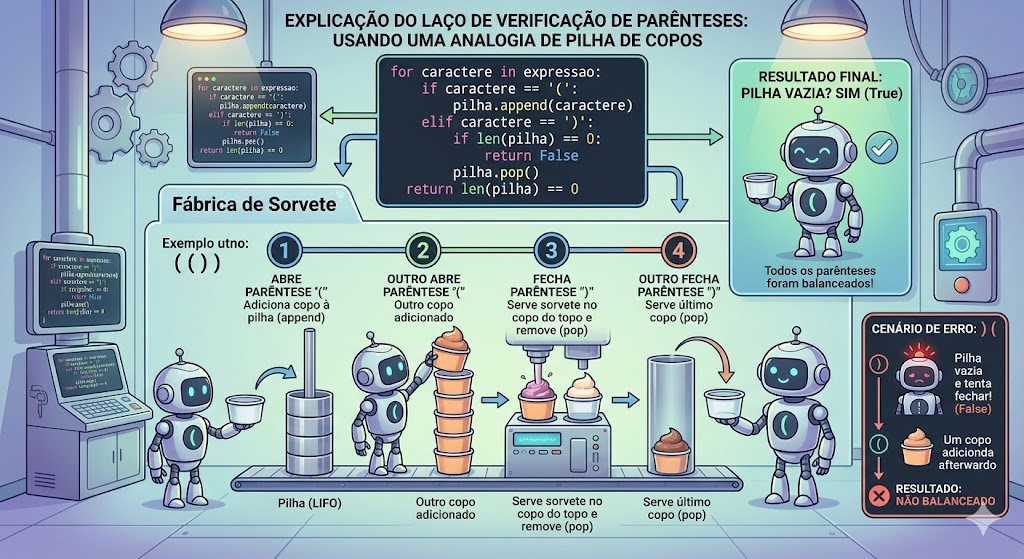

## 3. O Motor do Validador Completo
Nesta etapa, o Motorista assume o teclado. Implementem a função abaixo obedecendo as regras da PEP 8: uso de dicas de tipo (`Type Hints`) e documentação em `Docstrings`. Aqui a coisa complica: vamos estender a lógica para lidar com `()`, `[]` e `{}`.
Lembrem-se de que a classe nativa `list` do Python serve perfeitamente como pilha utilizando `.append()` e `.pop()`.

In [11]:
def validar_expressao(expressao: str) -> bool:
    """
    Analisa uma expressão matemática e retorna True se todos os 
    símbolos de associação (), [], {} estiverem balanceados corretamente.
    """
    pilha = []
    
    # Dicionário mapeando cada fechamento à sua respectiva abertura
    pares = {')': '(', ']': '[', '}': '{'}
    
    # --- COMPLETANDO AS LACUNAS ABAIXO ---
    aberturas = pares.values()    # Aqui você muda para .values()
    fechamentos = pares.keys()    # Aqui você muda para .keys()
    
    for caractere in expressao:
        # Se for abertura, fazemos o PUSH (adiciona no topo da pilha)
        if caractere in aberturas:
            pilha.append(caractere) # Aqui você muda para .append()
            
        # Se for fechamento, temos que avaliar usando o POP
        elif caractere in fechamentos:
            # Explicação da Proteção: Evita erro ao tentar remover de uma pilha vazia
            # Se a pilha está vazia e chegou um fechamento, a expressão é inválida.
            if len(pilha) == 0:
                return False
            
            topo = pilha.pop() # Aqui você muda para .pop()
            
            # Valida se o símbolo que fechou corresponde ao último que abriu
            if pares[caractere] != topo:
                return False
                
    # No final, se a pilha estiver vazia (0), tudo foi fechado.
    return len(pilha) == 0 # Aqui você muda para 0

## 4. Validação do Código Completo
Agora o Navegador assume o teclado (Inversão).
Vamos passar a nossa função por um "Teste de Estresse". Um bom algoritmo não deve funcionar apenas para o caminho feliz, ele deve saber identificar falhas complexas.

In [12]:
# 1. Expressão Válida e Aninhada
exp_valida = "{ [ ( a + b ) * c ] }"
print(f"Teste 1 (Válido): {validar_expressao(exp_valida)} - Esperado: True")

# 2. Expressão Inválida (Cruzamento de símbolos)
exp_invalida = "{ ( a + b } )"
print(f"Teste 2 (Inválido): {validar_expressao(exp_invalida)} - Esperado: False")

# 3. Teste de Estresse (Fechamento incorreto da ordem)
exp_estresse = "( [ ) ]"
print(f"Teste 3 (Estresse): {validar_expressao(exp_estresse)} - Esperado: False")

# 4. Falha Clássica (Abre tudo, mas esquece de fechar)
exp_incompleta = "( ( )"
print(f"Teste 4 (Incompleta): {validar_expressao(exp_incompleta)} - Esperado: False")

Teste 1 (Válido): True - Esperado: True
Teste 2 (Inválido): False - Esperado: False
Teste 3 (Estresse): False - Esperado: False
Teste 4 (Incompleta): False - Esperado: False


## 5. Check-out Gamificado (*Boss Fight*)
Chegou a hora de validar se sua implementação suporta **casos extremos**. Nós construímos um script de teste automático (o "Chefe Final"). Ele enviará expressões brutais para a sua função `validar_expressao`.

**Regras:**
1. Substitua a string da variável `nomes_da_dupla` pelo nome de vocês.
2. Rode a célula de código abaixo.
3. Se o código de vocês for robusto o suficiente e passar em 100% dos casos de teste, vocês receberão uma **Chave de Acesso** (um *Token* criptografado).

**Ação Final:** Anote a sua Chave de Acesso para comprovação da Avaliação Continuada e não esqueça de realizar o seu **Commit e Push** final no GitHub.

In [14]:
import hashlib
import time

# ----> PREENCHAM SEUS NOMES AQUI <----
nomes_da_dupla = "bruno"
# -----------------------------------

print("🚀 Iniciando Teste de Estresse do Validador LIFO...\n")
time.sleep(1)

# Array de tuplas contendo: (Expressão Estressante, Resultado Correto)
testes_secretos = [
    ("{[()()]}", True),               # Balanceado perfeitamente
    ("(((())))", True),               # Aninhamento profundo
    ("{[(])}", False),                # Cruzamento traiçoeiro
    ("[[[[[[[[]]]]]]]]", True),       # Carga pesada contínua
    ("())(()", False),                # Fechamento prematuro
    ("A equação: {[(2+3)*5] - 1}", True), # Expressão real misturada com texto
    ("{[()", False)                   # Fim abrupto com pilha cheia
]

passou_em_todos = True

for i, (expr, experado) in enumerate(testes_secretos):
    try:
        resultado = validar_expressao(expr)
        if resultado == experado:
            print(f"✅ Teste {i+1} Passou!")
        else:
            print(f"❌ Teste {i+1} Falhou...")
            print(f"   - Análise: O algoritmo errou. Ao receber a expressão '{expr}', o sistema esperava '{experado}', mas sua função retornou '{resultado}'.")
            passou_em_todos = False
    except Exception as e:
        print(f"⚠️ Teste {i+1} Quebrou! Erro na execução das listas no Python: {e}")
        passou_em_todos = False

print("-" * 40)
if passou_em_todos:
    semente = "AC_Aula06_" + nomes_da_dupla 
    chave = hashlib.md5(semente.encode()).hexdigest()[:8].upper()
    print("🏆 PARABÉNS! SEU ALGORITMO É À PROVA DE BALAS!")
    print(f"🔑 Chave de Acesso (Token de Autorização): LIFO-{chave}\n")
    print("Verificação do Laboratório Concluída com Sucesso! Façam o Commit e Push!")
else:
    print("🛑 ERRO(S) ENCONTRADO(S)!\nSeu algoritmo ainda tem falhas arquiteturais. Revise as condicionais da Lógica e rode novamente!")

🚀 Iniciando Teste de Estresse do Validador LIFO...

✅ Teste 1 Passou!
✅ Teste 2 Passou!
✅ Teste 3 Passou!
✅ Teste 4 Passou!
✅ Teste 5 Passou!
✅ Teste 6 Passou!
✅ Teste 7 Passou!
----------------------------------------
🏆 PARABÉNS! SEU ALGORITMO É À PROVA DE BALAS!
🔑 Chave de Acesso (Token de Autorização): LIFO-5D1FEEE6

Verificação do Laboratório Concluída com Sucesso! Façam o Commit e Push!
